# Scenario Comparison

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
from pypsa.statistics import get_transmission_carriers

# Add the scripts/pypsa-de directory to the path
scripts_path = os.path.join(os.path.dirname(os.getcwd()), "scripts", "pypsa-de")
sys.path.append(scripts_path)

from flexibility_plots_scenario_comparison import (
    get_capacities,
    plot_capacity_comparison,
)
from flexibility_utils import tech_colors, df_to_png, scenario_colors, sector_colors

from export_ariadne_variables import get_export_import

kwargs = {
    "groupby": ["bus", "carrier"],
    "at_port": True,
    "nice_names": False,
}

# Data Loading

In [2]:
f = "/home/julian-geis/Documents/06_PhD/02Flexibility/runs/"
run = "20260202-flex-main-scenarios-49cl-1H" # "20251110-flex-main-scenarios"  # "20251109-flex-4scenarios-27cl-1H"  # "20251023-flex-scenario-update" # "20251015-flex-scenario-update-27cl-3h" # "20251013_flex-scenarios-temporal-industry-load-27cl-3h"
scenarios = ["LowFlex", "LowBattery", "Base", "HighFlex"]
years = [2045]
clusters = 49

In [3]:
networks = {}
for scenario in scenarios:
    for year in years:
        fn = f"{f}/{run}/{scenario}/networks/base_s_{clusters}__none_{year}.nc"
        networks[(scenario, year)] = pypsa.Network(fn)

INFO:pypsa.network.io:New version 1.0.7 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [4]:
PLOT_DIR = f + run + "/plots/scenario_comparison/"
os.makedirs(PLOT_DIR, exist_ok=True)

In [5]:
# load variables
variables = {}
for scenario in scenarios:
    df = (
        pd.read_excel(
            f"{f}/{run}/{scenario}/ariadne/exported_variables_full.xlsx",
            index_col=list(range(5)),
            # index_col=["Model", "Scenario", "Region", "Variable", "Unit"],
            sheet_name="data",
        )
        .groupby(["Variable", "Unit"], dropna=False)
        .sum()
    ).round(5)
    variables[scenario] = df

In [6]:
assert 0

AssertionError: 

# Functions

In [ ]:
def plot_variable(variable_name, varibales, scenarios, unit=None):
    fig, ax = plt.subplots(figsize=(6, 4))

    for scenario in scenarios:
        data = variables[scenario].loc[variable_name]

        if (unit is None) & (data.index[0] is not None):
            unit = data.index[0]
        elif unit is None:
            unit = "Unspecified unit"

        years = [int(col) for col in data.columns]
        ax.plot(
            years, data.values[0], marker="*", label=scenario, linewidth=2, markersize=8
        )

        # Set x-axis to show only the years in the data
        if years is not None:
            ax.set_xticks(years)

    ax.set_xlabel("Year")
    ax.set_ylabel(unit if unit and pd.notna(unit) else "Value")
    ax.set_title(variable_name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# calc system cost
def get_tsc(n, region, return_full=False):
        pypsa.options.set_option("params.statistics.drop_zero", False)
        capex = n.statistics.capex(
            groupby=pypsa.statistics.groupers["name", "carrier"], nice_names=False
        )
        opex = n.statistics.opex(
            groupby=pypsa.statistics.groupers["name", "carrier"], nice_names=False
        )
        # filter inter country transmission lines and links
        inter_country_lines = n.lines.bus0.map(n.buses.country) != n.lines.bus1.map(
            n.buses.country
        )
        inter_country_links = n.links.bus0.map(n.buses.country) != n.links.bus1.map(
            n.buses.country
        )
        transmission_carriers = get_transmission_carriers(n).get_level_values("carrier")
        transmission_lines = n.lines.carrier.isin(transmission_carriers) & n.lines.active
        transmission_links = n.links.carrier.isin(transmission_carriers) & n.links.active
        country_transmission_lines = (
            (n.lines.bus0.str.contains(region)) & ~(n.lines.bus1.str.contains(region))
        ) | (~(n.lines.bus0.str.contains(region)) & (n.lines.bus1.str.contains(region)))
        country_transmission_links = (
            (n.links.bus0.str.contains(region)) & ~(n.links.bus1.str.contains(region))
        ) | (~(n.links.bus0.str.contains(region)) & (n.links.bus1.str.contains(region)))
        inter_country_transmission_lines = (
            inter_country_lines & transmission_lines & country_transmission_lines
        )
        inter_country_transmission_links = (
            inter_country_links & transmission_links & country_transmission_links
        )
        inter_country_transmission_lines_i = inter_country_transmission_lines[
            inter_country_transmission_lines
        ].index
        inter_country_transmission_links_i = inter_country_transmission_links[
            inter_country_transmission_links
        ].index
        inter_country_transmission_i = inter_country_transmission_lines_i.union(
            inter_country_transmission_links_i
        )
        tsc = pd.concat([capex, opex], axis=1, keys=["capex", "opex"])
        tsc = tsc.reset_index().set_index("name")
        tsc.loc[inter_country_transmission_i, ["capex", "opex"]] = (
            tsc.loc[inter_country_transmission_i, ["capex", "opex"]] / 2
        )
        tsc.rename(
            index={index: index + " " + region for index in inter_country_transmission_i},
            inplace=True,
        )
        # rename inter region links and lines
        to_rename_links = n.links[
            (n.links.bus0.str.contains(region))
            & (n.links.bus1.str.contains(region))
            & ~(n.links.index.str.contains(region))
        ].index
        to_rename_lines = n.lines[
            (n.lines.bus0.str.contains(region))
            & (n.lines.bus1.str.contains(region))
            & ~(n.lines.index.str.contains(region))
        ].index
        tsc.rename(
            index={index: index + " " + region for index in to_rename_links},
            inplace=True,
        )
        tsc.rename(
            index={index: index + " " + region for index in to_rename_lines},
            inplace=True,
        )
        tsc = tsc.filter(like=region, axis=0)
        tsc_sum = tsc.drop("component", axis=1).groupby("carrier").sum()

        if return_full:
            return tsc_sum, tsc
        return tsc_sum

def get_trade_cost(n, region, carriers):
    """
    Positive values mean cost for the domestic energy system (imports > exports)
    Negative values mean revenue for the domestic energy system (exports > imports)
    """
    export_revenue, import_cost = get_export_import(n, region, carriers, unit="€")
    return import_cost - export_revenue

 # Define sector mapping
bus_carrier_to_sector = {
    "Electricity": [
        "AC", 
        "low voltage",
        "battery",
        "iron-air battery", 
        "EV battery",
        "home battery",
        "DSM"
    ],
    "Heat": [
        "urban central heat",
        "urban central water tanks",
        "urban central water pits",
        "rural heat",
        "rural water tanks",
        "urban decentral heat",
        "urban decentral water tanks"
    ],
    "H2": [
        "H2"
    ],
    "Gas": [
        "gas",
        "gas primary",
        "biogas",
        "gas for industry",
        "renewable gas"
    ],
    "Coal": [
        "lignite",
        "coal",
        "coal for industry"
    ],
    "Fuels": [
        "oil",
        "oil primary",
        "land transport oil",
        "shipping oil",
        "kerosene for aviation",
        "agriculture machinery oil",
        "renewable oil",
        "naphtha for industry",
        "methanol",
        "industry methanol",
        "shipping methanol",
    ],
    "Biomass": [
        "solid biomass",
        "solid biomass for industry"
    ],
    "CO2": [
        "co2",
        "co2 stored",
        "co2 sequestered",
        "process emissions"
    ]
}

# Function to get bus for each component
def get_component_bus(row, n):
    """Get the bus for a component based on its type."""
    name = row.name
    component = row['component']
    
    if component == 'Generator':
        return n.generators.loc[name, 'bus'] if name in n.generators.index else None
    elif component == 'Store':
        return n.stores.loc[name, 'bus'] if name in n.stores.index else None
    elif component == 'StorageUnit':
        return n.storage_units.loc[name, 'bus'] if name in n.storage_units.index else None
    elif component == 'Link':
        # For links, use bus1 (output bus) - adjust if needed
        return n.links.loc[name, 'bus1'] if name in n.links.index else n.links[n.links.carrier == row.carrier].bus1.head(1).values[0]
    elif component == 'Load':
        return n.loads.loc[name, 'bus'] if name in n.loads.index else None
    elif component == 'Line':
            return "DE0 0"
    else:
        return None

# Map bus to sector
def map_bus_to_sector(bus_name, n, bus_carrier_to_sector):
    """Map a bus to its sector based on carrier."""
    if pd.isna(bus_name):
        return "Other"
    
    # Get bus carrier
    if bus_name in n.buses.index:
        bus_carrier = n.buses.loc[bus_name, 'carrier']
    else:
        return "Other"
    
    # Find matching sector
    for sector, carriers in bus_carrier_to_sector.items():
        if bus_carrier in carriers:
            return sector
    
    return "Other"

def plot_price_duration_curves(
    networks,
    year,
    scenarios,
    carriers=["AC", "low voltage"],
    regions=["DE"],
    scenario_colors=scenario_colors,
    output_dir=None,
    ylim=(-50, 500),
    table_smaller=1,
    table_bigger=300,
    close_plot=True,
):
    """Plot electricity price duration curves comparison across scenarios and years."""
    fig, ax = plt.subplots(figsize=(8, 5))
    scenario_data = {}
    
    # ---- Process each scenario ----
    for scenario in scenarios:
        n = networks[(scenario, year)]
        buses = (
            n.buses[
                n.buses.carrier.isin(carriers)
                & n.buses.index.str.startswith(tuple(regions))
            ].index
        )
        lmps = n.buses_t.marginal_price[buses].values.flatten()
        lmps_sorted = np.sort(lmps)[::-1]
        pct = np.arange(len(lmps_sorted)) / len(lmps_sorted) * 100
        ax.plot(
            pct,
            lmps_sorted,
            label=scenario,
            color=scenario_colors[scenario],
            linewidth=2,
        )
        # metrics
        scenario_data[scenario] = {
            "avg": lmps_sorted.mean(),
            "std": lmps_sorted.std(),
            f"<{table_smaller}": (lmps_sorted < table_smaller).mean() * 100,
            f">{table_bigger}": (lmps_sorted > table_bigger).mean() * 100,
        }
    
    # Calculate dynamic position for quantile labels based on ylim
    y_range = ylim[1] - ylim[0]
    label_y_position = ylim[0] + 0.02 * y_range  # 5% above the bottom
    
    # ---- Vertical quantile lines (x in %) ----
    quantiles = [0, 10, 25, 50, 75, 100]
    for q in quantiles:
        ax.axvline(q, ls="--", lw=0.8, color="grey", alpha=0.5)
        ax.text(q + 0.5, label_y_position, f"{q}%", rotation=90, fontsize=8, alpha=0.7)
    
    ax.set(
        ylim=ylim,
        xlim=(-5, 105),  # Added negative space on x-axis
        xlabel="Percentage of time",
        ylabel="€/MWh",
        # title=f"Price duration curves {year}",
    )
    ax.grid(alpha=0.3, linestyle=':')
    
    # ---- Create fancy compact table ----
    table_data = []
    for sc in scenarios:
        m = scenario_data[sc]
        table_data.append([
            sc,
            f"{m['avg']:.2f}",
            f"{m['std']:.2f}",
            f"{m[f'<{table_smaller}']:.0f}%",
            f"{m[f'>{table_bigger}']:.0f}%",
        ])
    
    col_labels = ["Scenario", "Avg", "Std", f"<{table_smaller}", f">{table_bigger}"]
    table = plt.table(
        cellText=table_data,
        colLabels=col_labels,
        loc="upper right",
        cellLoc="center",
        colColours=["#34495e"] * len(col_labels),
        fontsize=7,
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(6.5)
    table.scale(0.5, 1.2)  # Reduce narrower columns
    
    # Color the scenario cells
    for i, sc in enumerate(scenarios, start=1):
        table[i, 0].set_facecolor(scenario_colors[sc])
        table[i, 0].set_text_props(weight='bold', color='white')
    
    # Style header row
    for j in range(len(col_labels)):
        table[0, j].set_text_props(weight='bold', color='white', fontsize=6.5)
    
    plt.tight_layout()
    if output_dir:
        plt.savefig(output_dir, bbox_inches="tight", dpi=300)
    if close_plot:
        plt.close()
    else:
        plt.show()

def bar_plot_variables(variables, 
                         scenarios, 
                         years,
                         tech_colors, 
                         plot_vars=None,
                         sign_flip_vars=["Electricity", "Hydrogen", "eFuels"],
                         title=None, 
                         ylabel="TWh/a",
                         output_dir=None):
    """Plot multiple trade variables across scenarios for each year in one plot."""
    
    
    # Define the default variables to plot
    if plot_vars is None:
        plot_vars = {
            "Electricity": "Trade|Secondary Energy|Electricity|Volume",
            "Gas": "Primary Energy|Gas",
            "Oil": "Primary Energy|Oil",
            "Hydrogen": "Trade|Secondary Energy|Hydrogen|Volume", 
            "eFuels": "Trade|Secondary Energy|Efuels|Volume",
            "Biomass": "Trade|Primary Energy|Biomass|Net Imports",
        }
    
    for year in years:
        fig, ax = plt.subplots(figsize=(10, 5))
        
        # Prepare data
        data = {var_name: [] for var_name in plot_vars.keys()}
        
        for scenario in scenarios:
            df = variables[scenario]
            for var_name, var_path in plot_vars.items():
                try:
                    # Extract scalar value properly
                    value = df.loc[var_path, year]
                    # Convert to scalar if it's a Series
                    if hasattr(value, 'values'):
                        value = value.values[0]
                    # Convert to float to ensure it's a scalar
                    value = float(value)
                    # Multiply by -1 for Electricity and Hydrogen
                    if var_name in sign_flip_vars:
                        value = value * -1
                except (KeyError, IndexError):
                    value = 0.0
                
                data[var_name].append(value)
        
        # Set up bar positions
        x = np.arange(len(scenarios))
        n_vars = len(plot_vars)
        width = 0.15  # Width of each bar
        
        # Calculate offset to center the group of bars
        total_width = width * n_vars
        start_offset = -total_width / 2 + width / 2
        
        # Plot bars for each variable
        for i, var_name in enumerate(plot_vars.keys()):
            offset = start_offset + width * i
            color = tech_colors.get(var_name if var_name != "Hydrogen" else "H2", "gray")
            bars = ax.bar(x + offset, data[var_name], width, 
                          label=var_name,
                          color=color,
                          edgecolor='black', 
                          linewidth=1.2,
                          alpha=0.85)
            
            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                if abs(height) > 0.5:  # Only show labels for non-negligible values
                    if height >= 0:
                        va = 'bottom'
                        y_pos = height
                    else:
                        va = 'top'
                        y_pos = height
                    ax.text(bar.get_x() + bar.get_width() / 2., y_pos,
                           f'{height:.1f}',
                           ha='center', va=va, fontsize=8, fontweight='bold')
        
        # Customize plot
        ax.set_xticks(x)
        ax.set_xticklabels(scenarios, fontsize=11, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12)
        ax.legend(loc='best', fontsize=10, framealpha=0.9)
        ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1)
        ax.axhline(y=0, color='black', linewidth=1.5)
        
        if title:
            ax.set_title(title, fontsize=13, fontweight='bold')
        
        plt.tight_layout()
        if output_dir:
            plt.savefig(output_dir + f"trade_variables_{year}.png", bbox_inches="tight", dpi=300)


def plot_curtailment(networks, scenarios, year, tech_colors, output_dir=None):
    """Plot curtailment for wind and solar technologies across scenarios."""
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Define technology groupings
    wind_techs = ['onwind', 'offwind-ac', 'offwind-dc']
    solar_techs = ['solar', 'solar rooftop', 'solar-hsat']
    
    # Prepare data structure
    scenario_data = {sc: {'wind': {}, 'solar': {}} for sc in scenarios}
    
    for scenario in scenarios:
        n = networks[(scenario, year)]
        
        # Calculate curtailment
        curtailment = (
            n.statistics.curtailment(bus_carrier=["AC", "low voltage"], **kwargs)
            .filter(like="DE")
            .groupby("carrier")
            .sum()
        )
        
        # Extract wind data
        for tech in wind_techs:
            if tech in curtailment.index:
                scenario_data[scenario]['wind'][tech] = curtailment[tech] / 1e6  # Convert to TWh
            else:
                scenario_data[scenario]['wind'][tech] = 0.0
        
        # Extract solar data
        for tech in solar_techs:
            if tech in curtailment.index:
                scenario_data[scenario]['solar'][tech] = curtailment[tech] / 1e6  # Convert to TWh
            else:
                scenario_data[scenario]['solar'][tech] = 0.0
    
    # Set up bar positions
    x = np.arange(len(scenarios))
    width = 0.35

    # Plot wind bars (left)
    bottom_wind = np.zeros(len(scenarios))
    for tech in wind_techs:
        values = [scenario_data[sc]['wind'][tech] for sc in scenarios]
        ax.bar(x - width/2, values, width, bottom=bottom_wind,
               label=tech, color=tech_colors[tech], edgecolor='black', linewidth=0.5)
        bottom_wind += values
    
    # Plot solar bars (right)
    bottom_solar = np.zeros(len(scenarios))
    for tech in solar_techs:
        values = [scenario_data[sc]['solar'][tech] for sc in scenarios]
        ax.bar(x + width/2, values, width, bottom=bottom_solar,
               label=tech, color=tech_colors[tech], edgecolor='black', linewidth=0.5)
        bottom_solar += values
    
    # Calculate max value for y-axis limit
    max_value = max(max(bottom_wind), max(bottom_solar))
    
    # Add only total sum labels on top of bars
    for i, scenario in enumerate(scenarios):
        wind_total = sum(scenario_data[scenario]['wind'].values())
        solar_total = sum(scenario_data[scenario]['solar'].values())
        
        # Sum on top of bars
        if wind_total > 0:
            ax.text(x[i] - width/2, wind_total + 1, f'{wind_total:.1f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        if solar_total > 0:
            ax.text(x[i] + width/2, solar_total + 1, f'{solar_total:.1f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Customize plot
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, fontsize=11, fontweight='bold')
    ax.set_ylabel("TWh/a", fontsize=12)
    # ax.set_title(f"Renewable Curtailment - {year}", fontsize=13, fontweight='bold')
    
    # Set y-axis limit with extra space at top (15% more than max value)
    ax.set_ylim(0, max_value * 1.15)
    
    # Create legend in upper right
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='upper right', fontsize=9, framealpha=0.9, ncol=2)
    
    ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=1)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(f"{output_dir}/curtailment_{year}.png", bbox_inches="tight", dpi=300)

def plot_energy_system_cost_comparison(
    df, 
    scenarios=['LowFlex', 'LowBattery', 'Base', 'HighFlex'],
    sectors=['Electricity', 'Heat', 'H2', 'Fuels', 'Gas', 'Biomass', 'Other'],
    colors=None,
    save_path=None,
    figsize=(8, 5)
):
    """
    Plot total energy system cost comparison across scenarios.
    
    Left bars show costs stacked by type (CAPEX, OPEX, Trade).
    Right bars show costs stacked by sector within each cost type.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with cost data indexed by cost categories (e.g., 'CAPEX Electricity')
        and columns for each scenario
    scenarios : list
        List of scenario names (columns in df)
    sectors : list
        List of sector names to extract from the index
    tech_colors : dict, optional
        Color mapping for technologies/sectors. If None, uses default colors.
    year : int or str, optional
        Year to include in the saved filename
    save_path : str, optional
        Full path to save the figure. If None, doesn't save.
    figsize : tuple
        Figure size (width, height)
        
    Returns
    -------
    fig, ax : matplotlib Figure and Axes objects
    """

    
    # Extract data by cost type (left bar)
    capex = np.array([df.filter(like='CAPEX', axis=0)[scenario].sum() for scenario in scenarios])
    opex = np.array([df.filter(like='OPEX', axis=0)[scenario].sum() for scenario in scenarios])
    trade = np.array([df.filter(like='Trade', axis=0)[scenario].sum() for scenario in scenarios])
    total = capex + opex + trade
    
    # Extract data by sector AND cost type (right bar)
    sector_capex = np.zeros((len(scenarios), len(sectors)))
    sector_opex = np.zeros((len(scenarios), len(sectors)))
    sector_trade = np.zeros((len(scenarios), len(sectors)))
    
    for i, scenario in enumerate(scenarios):
        for j, sector in enumerate(sectors):
            sector_capex[i, j] = df[df.index.str.contains(f'CAPEX.*{sector}')][scenario].sum()
            sector_opex[i, j] = df[df.index.str.contains(f'OPEX.*{sector}')][scenario].sum()
            sector_trade[i, j] = df[df.index.str.contains(f'Trade.*{sector}')][scenario].sum()
    
    # Calculate % difference from Base scenario
    base_idx = scenarios.index('Base') if 'Base' in scenarios else None
    if base_idx is not None:
        base_total = total[base_idx]
        pct_diff = (total - base_total) / base_total * 100
    else:
        pct_diff = np.zeros(len(scenarios))
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(scenarios))
    width = 0.35
    
    # Left bar: stacked by cost type
    ax.bar(x - width/2, capex, width, color='thistle')
    ax.bar(x - width/2, opex, width, bottom=capex, color='pink')
    ax.bar(x - width/2, trade, width, bottom=capex+opex, color='navajowhite')
    
    # Add horizontal text labels on left bars
    for i in range(len(scenarios)):
        ax.text(i - width/2, capex[i]/2, 'CAPEX', ha='center', va='center', 
                fontsize=9, fontweight='bold', color='white')
        ax.text(i - width/2, capex[i] + opex[i]/2, 'OPEX', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
        ax.text(i - width/2, capex[i] + opex[i] + trade[i]/2, 'Trade', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
    
    # Add total cost labels on top of left bars
    for i in range(len(scenarios)):
        ax.text(i - width/2, total[i], f'{total[i]:.1f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Right bar: stack CAPEX by sector, then OPEX by sector, then Trade by sector
    bottom = np.zeros(len(scenarios))
    
    # First layer: CAPEX by sector
    for j, sector in enumerate(sectors):
        ax.bar(x + width/2, sector_capex[:, j], width, bottom=bottom, 
               color=colors[sector], label=sector, edgecolor='white', linewidth=0.5)
        bottom += sector_capex[:, j]
    
    capex_top = bottom.copy()
    
    # Second layer: OPEX by sector
    for j, sector in enumerate(sectors):
        ax.bar(x + width/2, sector_opex[:, j], width, bottom=bottom, 
               color=colors[sector], edgecolor='white', linewidth=0.5)
        bottom += sector_opex[:, j]
    
    opex_top = bottom.copy()
    
    # Third layer: Trade by sector
    for j, sector in enumerate(sectors):
        ax.bar(x + width/2, sector_trade[:, j], width, bottom=bottom, 
               color=colors[sector], edgecolor='white', linewidth=0.5)
        bottom += sector_trade[:, j]
    
    # Add thick horizontal lines between sections
    for i in range(len(scenarios)):
        ax.hlines(capex_top[i], i + width/2 - width/2, i + width/2 + width/2, 
                  colors='black', linewidth=2.5, zorder=10)
        ax.hlines(opex_top[i], i + width/2 - width/2, i + width/2 + width/2, 
                  colors='black', linewidth=2.5, zorder=10)
    
    # Add percentage labels (skip Base scenario)
    if base_idx is not None:
        for i, scenario in enumerate(scenarios):
            if scenario != 'Base':
                sign = '+' if pct_diff[i] > 0 else ''
                ax.text(i + width/2, total[i], f'{sign}{pct_diff[i]:.1f}%', 
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Formatting
    ax.set_ylabel('Cost (billion €)', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios)
    ax.legend(fontsize=9, ncol=4, loc='upper right', title='Sectors')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(total) * 1.3)
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax

# Filter vars

In [13]:
# filter for vars
search = "Price"
vars = variables["Base"].index.get_level_values("Variable").unique().to_list()
[v for v in vars if search in v]

['Price|Carbon',
 'Price|Carbon|EU-wide Regulation All Sectors',
 'Price|Carbon|National Climate Target',
 'Price|Final Energy|Industry|Electricity',
 'Price|Final Energy|Industry|Gases',
 'Price|Final Energy|Industry|Heat',
 'Price|Final Energy|Industry|Hydrogen',
 'Price|Final Energy|Industry|Liquids',
 'Price|Final Energy|Industry|Liquids|Efuel',
 'Price|Final Energy|Industry|Liquids|Oil',
 'Price|Final Energy|Industry|Solids',
 'Price|Final Energy|Industry|Solids|Biomass',
 'Price|Final Energy|Industry|Solids|Coal',
 'Price|Final Energy|Residential and Commercial|Electricity',
 'Price|Final Energy|Residential and Commercial|Gases',
 'Price|Final Energy|Residential and Commercial|Heat',
 'Price|Final Energy|Residential and Commercial|Liquids',
 'Price|Final Energy|Residential and Commercial|Liquids|Oil',
 'Price|Final Energy|Residential and Commercial|Solids',
 'Price|Final Energy|Residential and Commercial|Solids|Biomass',
 'Price|Final Energy|Transportation|Electricity',
 'Price|F

# System cost

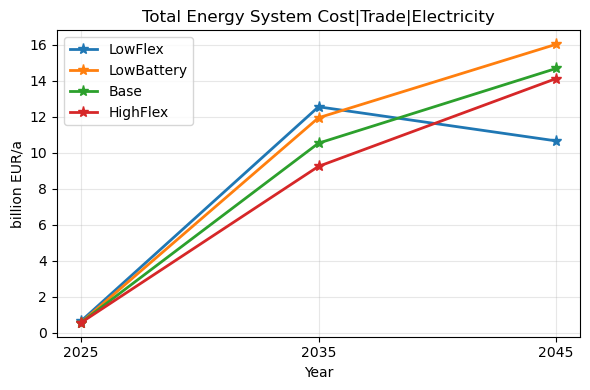

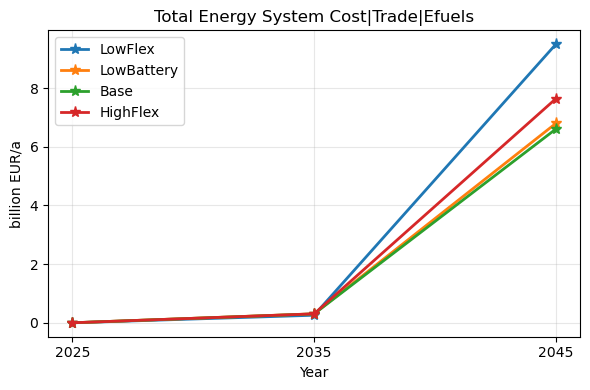

In [ ]:
# System costs
# plot_variable("Total Energy System Cost|Trade|Hydrogen", variables, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost|Trade|Electricity", variables, scenarios, unit="billion EUR/a")
plot_variable("Total Energy System Cost|Trade|Efuels", variables, scenarios, unit="billion EUR/a")
# plot_variable("Total Energy System Cost", variables, scenarios, unit="billion EUR/a")
# plot_variable("Total Energy System Cost|Non Trade", variables, scenarios, unit="billion EUR/a")
# plot_variable("Total Energy System Cost|Trade", variables, scenarios, unit="billion EUR/a")
# plot_variable("Total Energy System Cost|EU", variables, scenarios, unit="billion EUR/a")

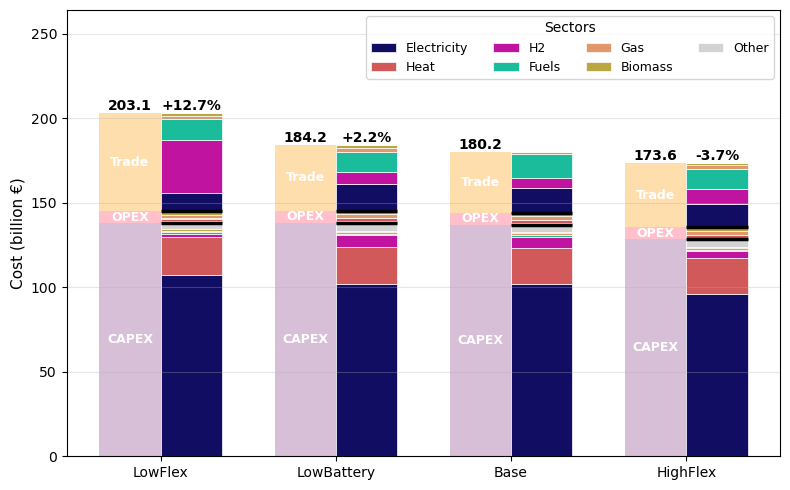

In [ ]:
# Plot system cost per year
system_cost_analysis = True
year = 2045

if system_cost_analysis:

    region = "DE"
    var_all = pd.DataFrame(columns=scenarios)
    tsc_all = {}

    for scenario in scenarios:
        try:
            n = networks[(scenario, year)]
        except KeyError:
            print(f"Network for scenario '{scenario}' and year '{year}' not found. Loading from file...")
            fn = f"{f}/{run}/{scenario}/networks/base_s_{clusters}__none_{year}.nc"
            n = pypsa.Network(fn)

        var = pd.Series()

        # equivalent to export_ariadne_variables script
        var["Total Energy System Cost|Trade|Electricity"] = (
            get_trade_cost(n, region, ["AC"]) + get_trade_cost(n, region, ["DC"])
        ) / 1e9
        var["Total Energy System Cost|Trade|eFuels"] = (
            get_trade_cost(n, region, ["renewable oil", "renewable gas", "methanol"]) / 1e9
        )
        var["Total Energy System Cost|Trade|H2"] = (
            get_trade_cost(
                n,
                region,
                ["H2 pipeline", "H2 pipeline (Kernnetz)", "H2 pipeline retrofitted"],
            )
            / 1e9
        )

        var["Total Energy System Cost|EU"] = (
            n.statistics.capex().sum() + n.statistics.opex().sum()
        ) / 1e9

        # different to export_ariadne_variables script         
        # Total Energy System Cost in billion EUR2020/yr
        tsc_sum, tsc = get_tsc(n, region)

        biomass_import_ind = tsc[tsc.index.str.contains("biomass transported")].index
        var["Total Energy System Cost|Trade|Biomass"] = tsc.loc[biomass_import_ind, "opex"].sum().sum() / 1e9
        tsc.loc[biomass_import_ind, "opex"] = 0

        gas_import_ind = tsc[tsc.carrier == "gas primary"].index
        var["Total Energy System Cost|Trade|Gas"] = tsc.loc[gas_import_ind, "opex"].sum().sum() / 1e9
        tsc.loc[gas_import_ind, "opex"] = 0

        oil_import_ind = tsc[tsc.carrier == "oil primary"].index
        var["Total Energy System Cost|Trade|Oil"] = tsc.loc[oil_import_ind, "opex"].sum().sum() / 1e9
        tsc.loc[oil_import_ind, "opex"] = 0

        tsc_all[scenario] = tsc

        # coal imports
        lignite_ind = n.links[(n.links.carrier=="lignite") & (n.links.bus1.str.contains("DE"))].index
        lignite_cost = (n.links_t.p0[lignite_ind].sum(axis=1) * n.buses_t.marginal_price["EU lignite"]).sum() / 1e9

        coal_ind = n.links[(n.links.carrier=="coal") & (n.links.bus1.str.contains("DE"))].index
        coal_cost = (n.links_t.p0[coal_ind].sum(axis=1) * n.buses_t.marginal_price["EU coal"]).sum() / 1e9

        var["Total Energy System Cost|Trade|Coal"] = lignite_cost + coal_cost

        var["Total Energy System Cost"] = (
            tsc_sum.sum().sum() / 1e9 
            + var["Total Energy System Cost|Trade|Electricity"] 
            + var["Total Energy System Cost|Trade|eFuels"]
            + var["Total Energy System Cost|Trade|H2"]
            + var["Total Energy System Cost|Trade|Coal"]
        )

        var["Total Energy System Cost|Trade"] = (
            var["Total Energy System Cost|Trade|Electricity"]
            + var["Total Energy System Cost|Trade|eFuels"]
            + var["Total Energy System Cost|Trade|H2"]
            + var["Total Energy System Cost|Trade|Biomass"]
            + var["Total Energy System Cost|Trade|Gas"]
            + var["Total Energy System Cost|Trade|Oil"]
            + var["Total Energy System Cost|Trade|Coal"]
        )

        var["Total Energy System Cost|Trade|Fuels"] = var["Total Energy System Cost|Trade|eFuels"] + var["Total Energy System Cost|Trade|Oil"]

        var["Total Energy System Cost|Non Trade"] = tsc[["capex", "opex"]].sum().sum() / 1e9

        assert abs(
            var["Total Energy System Cost"]
            - (
                var["Total Energy System Cost|Non Trade"]
                + var["Total Energy System Cost|Trade"]
            )
        ) < 1e-6

        # CAPEX & OPEX breakdown
        df = tsc 
        # Apply mappings
        df['bus'] = df.apply(lambda row: get_component_bus(row, n), axis=1)
        df['sector'] = df['bus'].apply(lambda x: map_bus_to_sector(x, n, bus_carrier_to_sector))

        # Sum by sector
        sector_costs = df.groupby('sector')[['capex', 'opex']].sum()

        for sector in ["Electricity", "Heat" ,"H2", "Fuels", "Gas", "Biomass"]:
            var["Total Energy System Cost|CAPEX|"+sector] = sector_costs.loc[sector, "capex"] / 1e9
            var["Total Energy System Cost|OPEX|"+sector] = sector_costs.loc[sector, "opex"] / 1e9

        other = [s for s in sector_costs.index if s not in ['Electricity', 'Heat' ,'H2', "Fuels", "Gas", "Biomass"]]
        var["Total Energy System Cost|CAPEX|Other"] = sector_costs.loc[other, "capex"].sum() / 1e9
        var["Total Energy System Cost|OPEX|Other"] = sector_costs.loc[other, "opex"].sum() / 1e9

        var["Total Energy System Cost|Trade|Other"] = (
            + var["Total Energy System Cost|Trade|Coal"]
        )
        
        var_all[scenario] = var

    df_to_png(round(var_all, 2), PLOT_DIR + f"system_cost_{year}.png")

    index_keep = [
        'Total Energy System Cost|CAPEX|Electricity',
        'Total Energy System Cost|CAPEX|Heat',
        'Total Energy System Cost|CAPEX|H2',
        'Total Energy System Cost|CAPEX|Fuels',
        'Total Energy System Cost|CAPEX|Gas',
        'Total Energy System Cost|CAPEX|Biomass',
        'Total Energy System Cost|CAPEX|Other',
        'Total Energy System Cost|OPEX|Electricity',
        'Total Energy System Cost|OPEX|Heat',
        'Total Energy System Cost|OPEX|H2',
        'Total Energy System Cost|OPEX|Fuels',
        'Total Energy System Cost|OPEX|Gas',
        'Total Energy System Cost|OPEX|Biomass',
        'Total Energy System Cost|OPEX|Other',
        'Total Energy System Cost|Trade|Electricity',
        'Total Energy System Cost|Trade|H2',
        'Total Energy System Cost|Trade|Fuels',
        'Total Energy System Cost|Trade|Gas',
        'Total Energy System Cost|Trade|Biomass',
        'Total Energy System Cost|Trade|Other',
    ]
    var_plot = pd.DataFrame(index=index_keep, columns=scenarios)

    for s in scenarios:
        var_plot[s] = var_all[s]

    assert np.isclose(var_plot.sum() , var_all.loc["Total Energy System Cost"]).all()

    df_to_png(round(var_plot, 2), PLOT_DIR + f"system_cost_plotted_{year}.png")

    fig, ax = plot_energy_system_cost_comparison(
        var_plot, 
        save_path=f"{PLOT_DIR}total_energy_system_cost_by_scenario_{year}.png",
        colors=sector_colors
    )
    plt.show()

In [ ]:
if system_cost_analysis:    
    res = pd.DataFrame()
    sector = "Electricity" # "Heat" # "Electricity" # "H2"
    for scenario in scenarios:

        df = tsc_all[scenario]
        res[scenario] = df[df.sector == sector].groupby(by="carrier").sum()[["capex"]]

    df = round(res/1e9,2)
    df_to_png(df[(df > 1).any(axis=1)], PLOT_DIR + f"system_cost_{sector}_{year}.png")
    df[(df > 1).any(axis=1)]

Results
=======

2035
────

Electricity
───────────
- AC/DC have similar values but decrease from scenarios with more flex
- LF and LB build more backup capacity from H2 CCGT and waste CHP (LF only)
- LF builds more onshore wind and less solar rooftop than rest
- LowFlex invests more into batteries than LowBattery as it builds more energy 
  capacity (similar to Base)
  LF invests much more into elctricity distribution grid

Heat
────
- LF generally builds more PtH capacity; especially more rural ground heat pumps 
  and urban decentral biomass boiler

H2
──
- LF builds no Electrolysis and HF less than other
- Kernnetz capacities are sufficient for all H2 transport in all scenarios 
  → maybe turn that off to see effect
  2035
────

2045
────
Electricity
───────────
- AC/DC have similar values but decrease from scenarios with more flex
- LF and LB build more backup capacity from H2 CCGT and waste CHP (LF only)
- LF builds more onshore wind and less solar rooftop than rest
- LowFlex invests more into batteries than LowBattery as it builds more energy 
  capacity (similar to Base)

Heat
────
- LF generally builds more PtH capacity; especially more rural ground heat pumps 
  and urban decentral biomass boiler

H2
──
- LF builds no Electrolysis and HF less than other
- Kernnetz capacities are sufficient for all H2 transport in all scenarios 
  → maybe turn that off to see effect

In [ ]:
# todo biomass potentials (biomass transported kann auch transport in DE sein)

# Capacity

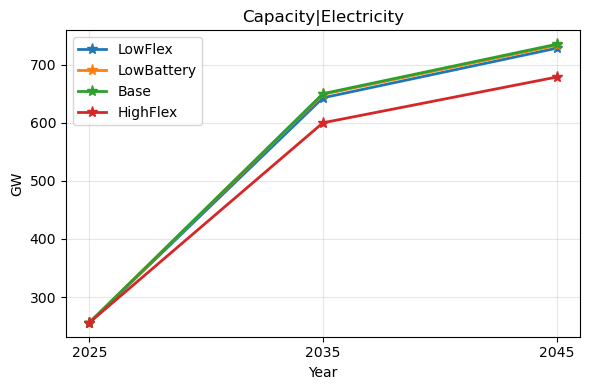

In [ ]:
plot_variable("Capacity|Electricity", variables, scenarios)
# plot_variable("Capacity|Electricity|Biomass", variables, scenarios)
# plot_variable("Capacity|Electricity|Coal", variables, scenarios)
# plot_variable("Capacity|Electricity|Gas", variables, scenarios)
# plot_variable("Capacity|Electricity|Solar", variables, scenarios)
# plot_variable("Capacity|Electricity|Wind", variables, scenarios)
# plot_variable("Capacity|Electricity|Storage Converter|Stationary Batteries", variables, scenarios)
# plot_variable("Capacity|Electricity|Storage Reservoir|Stationary Batteries", variables, scenarios)
# plot_variable("Capacity|Electricity|Storage Converter|Stationary Batteries", variables, scenarios)
# plot_variable("Capacity|Electricity|Transmission", variables, scenarios)

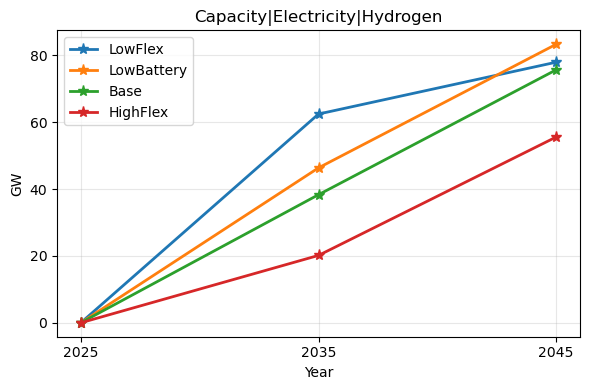

In [ ]:
# plot_variable("Capacity|Electricity|Gas", results, scenarios)
plot_variable("Capacity|Electricity|Hydrogen", variables, scenarios)

## Capacity Detailed

In [ ]:
for year in years:
    n = networks[("Base", year)]

    capacities_electricity = (
        n.statistics.optimal_capacity(
            bus_carrier=["AC", "low voltage"],
            **kwargs,
        )
        .filter(like="DE")
        .groupby("carrier")
        .sum()
        .drop(
            # transmission capacities
            ["AC", "DC", "electricity distribution grid"],
            errors="ignore",
        )
    )

    print(year)
    print(
        capacities_electricity[
            capacities_electricity.index.str.contains(
                "CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP", case=False
            )
        ]
        / 1e3
    )
    print()

2035
carrier
CCGT                         6.075900
H2 CCGT                      0.001929
H2 OCGT                     34.041113
H2 turbine                   0.038058
OCGT                         0.023310
urban central H2 CHP         4.284199
urban central gas CHP       19.891419
urban central gas CHP CC     0.000179
dtype: float64



## Export capacities csv

In [ ]:
new_capacity_export = False

if new_capacity_export:    
    
    path = "/home/julian-geis/repos/pypsa-de-flex/results"
    path = "/home/julian-geis/Documents/06_PhD/02Flexibility/runs"

    # current capacity setting runs
    # 27cl-1H: "20251110-flex-main-scenarios"
    # 27cl-3H: "20251103-flex-4scenarios-27cl-3H"
    # 49cl-3H: "20251107-flex-Base-49cl-3H"
    # 49cl-1H: "20251114-flex-Base-49cl-1H"


    run = "20251103-flex-4scenarios-27cl-3H"

    ## Note: the capacities df has to have the "groupby": ["bus", "carrier"] otherwise it cannot be used

    scenario = "MedFlex"
    years = [2025, 2035, 2045]
    clusters = 27
    hours = 3

    networks_capa = {}
    for year in years:
        fn = f"{path}/{run}/{scenario}/networks/base_s_{clusters}__none_{year}.nc"
        networks_capa[year] = pypsa.Network(fn)

    kwargs = {
        "groupby": ["bus", "carrier"],
        "nice_names": False,
    }

    results_dict = {}

    for year in years:
        n = networks_capa[year]
        capacities = (
            n.statistics.optimal_capacity(**kwargs)
            # .filter(like="DE")
        )
        results_dict[year] = capacities

    results_df = pd.concat(results_dict, axis=1)
    results_df.columns = years  # Clean up column names
    results_df.to_csv(f"{path}/{run}/{scenario}_capacities_{clusters}cl_{hours}H.csv")

In [ ]:
if new_capacity_export:
    current_carriers = [
        "battery discharger", "home battery discharger",
        "battery", "home battery",
        "H2 Store", 
        "rural water tanks", 
        "urban decentral water tanks", "urban decentral water pits", 
        "urban central water tanks", "urban central water pits"
    ]

    grouped = results_df.groupby(by="carrier").sum()
    print(round(grouped.loc[grouped.index.intersection(current_carriers)] / 1e3, 2))  # in GW / GWh

# Secondary Energy / Generation

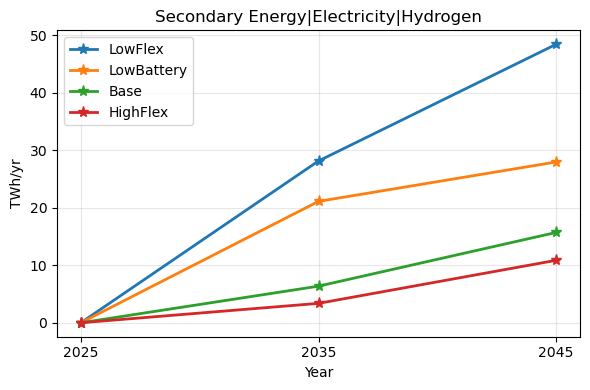

In [ ]:
# plot_variable("Secondary Energy|Electricity|Gas", variables, scenarios)
plot_variable("Secondary Energy|Electricity|Hydrogen", variables, scenarios)

In [ ]:
for year in years:
    n = networks[("Base", year)]

    generation_electricity = (
        n.statistics.supply(
            bus_carrier=["AC", "low voltage"],
            **kwargs,
        )
        .filter(like="DE")
        .groupby("carrier")
        .sum()
        .drop(
            # transmission capacities
            ["AC", "DC", "electricity distribution grid"],
            errors="ignore",
        )
    )

    print(year)
    print(
        generation_electricity[
            generation_electricity.index.str.contains(
                "CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP", case=False
            )
        ]
        / 1e6
    )
    print()

2035
carrier
CCGT                         5.170768
H2 CCGT                      0.002198
H2 OCGT                      3.439865
H2 turbine                   0.001879
OCGT                         0.002614
urban central H2 CHP         2.924058
urban central gas CHP       14.233423
urban central gas CHP CC     0.000215
dtype: float64



In [ ]:
# from flexibility_utils import scenario_abbrev

# # capacity grouping for scenario comparison plot
# capa_groups = {
#     "Wind + Solar": {
#         "Onshore wind": ["onwind"],
#         "Offshore wind": ["offwind-ac", "offwind-dc"],
#         "Solar": ["solar", "solar rooftop", "solar-hsat"],
#     },
#     "Backup": {
#         "Gas": ["OCGT", "CCGT"],
#         "Gas CHP": ["urban central gas CHP", "urban central gas CHP CC"],
#         "H2": ["H2 turbine", "H2 OCGT", "H2 CCGT"],
#         "H2 CHP": ["urban central H2 CHP"],
#         "Others": [
#             "coal",
#             "lignite",
#             "urban central coal CHP",
#             "urban central lignite CHP",
#             "solid biomass",
#             "urban central solid biomass CHP",
#             "urban central solid biomass CHP CC",
#             "waste CHP",
#             "waste CHP CC",
#             "oil",
#             "urban central oil CHP",
#             "H2 Fuel Cell",
#         ],
#     },
#     "Storage Discharge": {
#         "Pumped storage": ["PHS"],
#         "Battery": ["battery discharger", "home battery discharger"],
#         "Iron-air battery": ["iron-air battery discharger"],
#         "Vehicle-to-grid": ["V2G"],
#     },
#     "Demand-Side Flex": {
#         "Power-to-heat (central)": [
#             "urban central air heat pump",
#             "urban central resistive heater",
#         ],
#         "Power-to-heat (decentral)": [
#             "rural air heat pump",
#             "rural ground heat pump",
#             "rural resistive heater",
#             "urban decentral air heat pump",
#             "urban decentral resistive heater",
#         ],
#         "Electrolysis": ["H2 Electrolysis"],
#         "BEV charging": ["BEV charger"],
#         "Industry DSM": ["industry DSM ramp down"],
#         # "Fischer-Tropsch": ["Fischer-Tropsch"],
#     },
# }


# def get_capacities(networks, scenarios, years, max_usage=None):
#     """Extract and group capacities for all scenarios and years
    
#     Parameters
#     ----------
#     max_usage : list, optional
#         List of carrier names for which to use maximum usage instead of capacity
#     """
#     if max_usage is None:
#         max_usage = []
    
#     kwargs = {"groupby": ["bus", "carrier"], "at_port": True, "nice_names": False}
#     all_data = {}
    
#     for scenario in scenarios:
#         for year in years:
#             n = networks[scenario][year]
            
#             # Get capacities
#             caps = (
#                 n.statistics.optimal_capacity(
#                     bus_carrier=["AC", "low voltage"], **kwargs
#                 )
#                 .filter(like="DE")
#                 .groupby("carrier")
#                 .sum()
#                 .drop(["AC", "DC", "electricity distribution grid"], errors="ignore")
#             )
            
#             # Get maximum usage for specified carriers
#             if max_usage:
#                 ct = "DE"
#                 buses = n.buses.index[(n.buses.index.str[:2] == ct)].drop("DE", errors="ignore")
#                 balance = (
#                     n.statistics.energy_balance(
#                         aggregate_time=False,
#                         nice_names=False,
#                         groupby=["bus", "carrier", "bus_carrier"],
#                     )
#                     .loc[:, buses, :, :]
#                     .droplevel(["component", "bus"])
#                 )
#                 carriers = ["AC", "low voltage"]
#                 mask = balance.index.get_level_values("bus_carrier").isin(carriers)
#                 nb = balance[mask].groupby("carrier").sum().T
                
#                 # Replace capacities with max usage for specified carriers
#                 for carrier in max_usage:
#                     if carrier in nb.columns:
#                         max_val = nb[carrier].abs().max()  # in MW, matches caps units
#                         if carrier in caps.index:
#                             caps.loc[carrier] = max_val
            
#             # Group by technology
#             grouped = {}
#             for group_name, techs in capa_groups.items():
#                 grouped[group_name] = {}
#                 for tech_name, carrier_list in techs.items():
#                     val = caps[caps.index.isin(carrier_list)].sum()
#                     grouped[group_name][tech_name] = abs(val) / 1000  # Convert to GW
            
#             all_data[(scenario, year)] = grouped
    
#     return all_data


def plot_capacity_comparison(data, scenarios, years, tech_colors, max_usage=None):
    """Create stacked bar chart comparing scenarios across years
    
    Parameters
    ----------
    max_usage : list, optional
        List of technology names where max usage is plotted instead of capacity
    """
    if max_usage is None:
        max_usage = []
    
    fig, axes = plt.subplots(
        len(years),
        4,
        figsize=(16, 4 * len(years)),
        gridspec_kw={"wspace": 0.3, "hspace": 0.4},
    )
    if len(years) == 1:
        axes = axes.reshape(1, -1)
    
    group_names = list(capa_groups.keys())
    x = np.arange(len(scenarios))
    width = 0.6
    
    for year_idx, year in enumerate(years):
        for group_idx, group_name in enumerate(group_names):
            ax = axes[year_idx, group_idx]
            tech_names = list(capa_groups[group_name].keys())
            bottoms = np.zeros(len(scenarios))
            
            for tech_name in tech_names:
                values = [
                    data[(sc, year)][group_name].get(tech_name, 0) for sc in scenarios
                ]
                color = tech_colors.get(tech_name, "#CCCCCC")
                hatch = None
                if "CHP" in tech_name:
                    hatch = "//"
                elif "decentral" in tech_name:
                    hatch = "\\\\"
                
                # Add asterisk to label if it's in max_usage list
                label = tech_name + "*" if tech_name in max_usage else tech_name
                
                bars = ax.bar(
                    x,
                    values,
                    width,
                    bottom=bottoms,
                    color=color,
                    label=label,
                    hatch=hatch,
                    edgecolor="white" if hatch else None,
                    linewidth=0.5,
                )
                
                # Add value labels
                for i, (bar, val) in enumerate(zip(bars, values)):
                    if val > 1:
                        ax.text(
                            bar.get_x() + bar.get_width() / 2,
                            bottoms[i] + val / 2,
                            f"{int(val)}",
                            ha="center",
                            va="center",
                            fontsize=9,
                            color="white",
                            weight="bold",
                        )
                bottoms += values
            
            # Add total on top
            for i, total in enumerate(bottoms):
                if total > 0:
                    ax.text(
                        i,
                        total + max(bottoms) * 0.02,
                        f"{int(total)}",
                        ha="center",
                        va="bottom",
                        fontsize=10,
                        weight="bold",
                    )
            
            # Formatting
            ax.set_xticks(x)
            ax.set_xticklabels([scenario_abbrev.get(sc, sc[:4]) for sc in scenarios])
            ax.set_ylabel("Installed capacity (GW)", fontsize=10)
            ax.set_ylim(0, max(bottoms) * 1.15)
            ax.grid(axis="y", alpha=0.3)
            
            if year_idx == 0:
                ax.set_title(group_name, fontsize=12, weight="bold")
            if group_idx == len(group_names) - 1:
                ax.text(
                    1.05,
                    0.5,
                    str(year),
                    transform=ax.transAxes,
                    rotation=270,
                    va="center",
                    fontsize=14,
                    weight="bold",
                )
            ax.set_xlabel("Scenario", fontsize=10)
            
            # Add legend below (only for bottom row)
            if year_idx == len(years) - 1:
                handles, labels = ax.get_legend_handles_labels()
                
                ax.legend(
                    handles,
                    labels,
                    loc="upper center",
                    bbox_to_anchor=(0.5, -0.15),
                    ncol=1,
                    fontsize=9,
                    frameon=False,
                )
                
                # Add asterisk note only in the bottom-right subplot
                if group_idx == len(group_names) - 1 and max_usage:
                    ax.text(
                        0.1,
                        -0.55,
                        "* Maximum capacity usage instead of installed capacity",
                        transform=ax.transAxes,
                        ha="center",
                        fontsize=10,
                        style="italic",
                    )
    
    plt.tight_layout()
    return fig

# import importlib
# import flexibility_utils
# importlib.reload(flexibility_utils)
# from flexibility_utils import tech_colors

/tmp/ipykernel_539865/3236372631.py:254: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



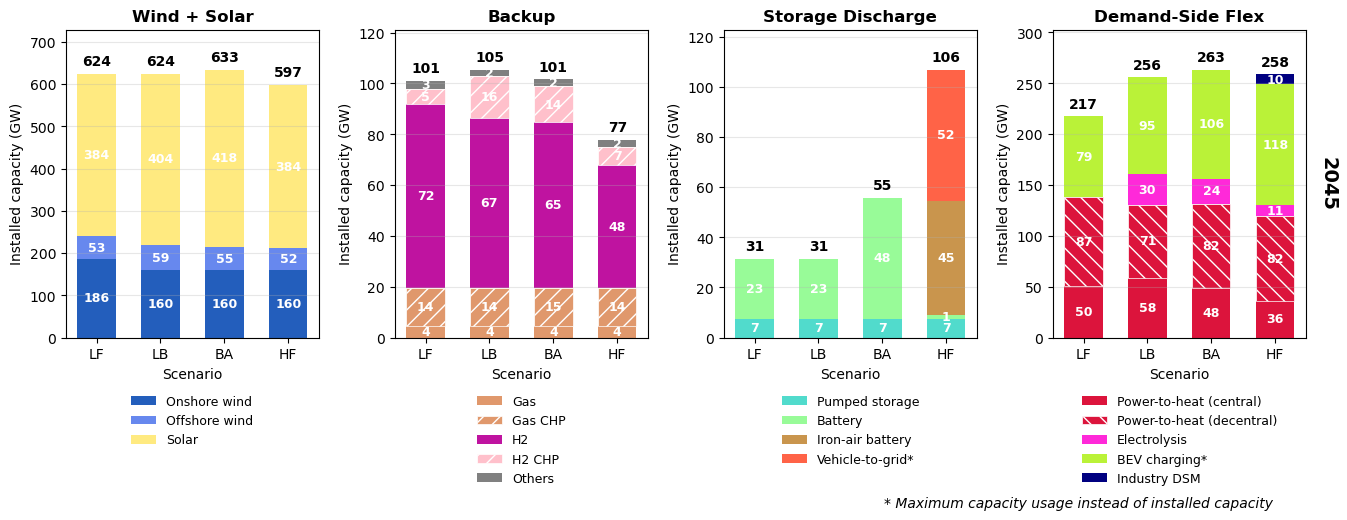

In [ ]:
# Convert networks from flat structure to nested structure to use repo function
# From: networks[(scenario, year)]
# To:   networks[scenario][year]

networks_nested = {}
for (scenario, year), network in networks.items():
    if scenario not in networks_nested:
        networks_nested[scenario] = {}
    networks_nested[scenario][year] = network

data = get_capacities(networks_nested, scenarios, years, max_usage=["BEV charger", "V2G"])
fig = plot_capacity_comparison(
    data, 
    scenarios, 
    years, 
    tech_colors,
    max_usage=["Vehicle-to-grid", "BEV charging"]
)

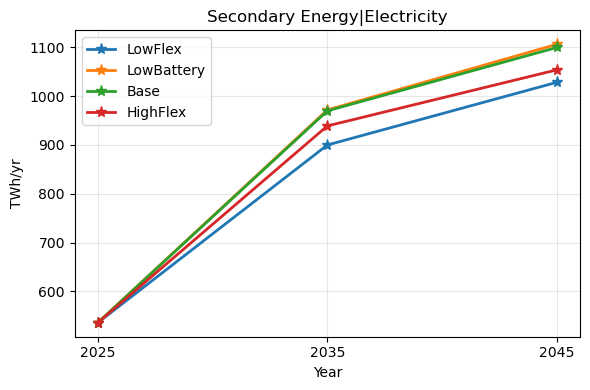

In [ ]:
# Generation
plot_variable("Secondary Energy|Electricity", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Biomass", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Coal", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Gas", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Solar", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Wind", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Curtailment", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Storage Losses", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Hydrogen", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Nuclear", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Hydro", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Waste", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Fossil", variables, scenarios)
# plot_variable("Secondary Energy|Electricity|Non-Biomass Renewables", variables, scenarios)

# Prices

In [ ]:
PRICE_DIR = PLOT_DIR + "prices/"
os.makedirs(PRICE_DIR, exist_ok=True)

In [ ]:
years = [2045]

for scenario in scenarios:
    for year in years:
        try:
            n = networks[(scenario, year)]
        except KeyError:
            print(f"Network for scenario '{scenario}' and year '{year}' not found. Loading from file...")
            fn = f"{f}/{run}/{scenario}/networks/base_s_{clusters}__none_{year}.nc"
            networks[(scenario, year)] = pypsa.Network(fn)

In [ ]:
price_carriers_to_plot = [
    ["AC", "low voltage"],
    ["urban central heat"],
    ["urban decentral heat"],
    ["rural heat"],
    ["urban central heat", "urban decentral heat", "rural heat"],
    ["H2"],
    ["gas"],
    ["renewable gas"],
    ["methanol"],
    ["renewable oil"],
    ["oil"],
]

for c in price_carriers_to_plot:
    plot_price_duration_curves(
        networks,
        year,
        scenarios,
        carriers=c,
        regions=["DE"],
        scenario_colors=scenario_colors,
        output_dir=PRICE_DIR + f"pdc_{'_'.join(c)}_{year}.png",
        ylim=(-50, 500),
        table_smaller=1,
        table_bigger=200,
    )

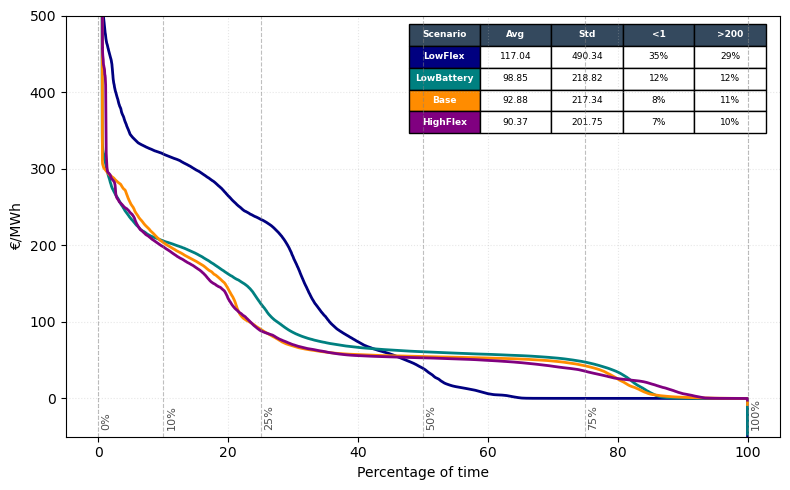

In [ ]:
carriers = ["AC", "low voltage"] # 

plot_price_duration_curves(
    networks,
    year,
    scenarios,
    carriers=carriers,
    regions=["DE"],
    scenario_colors=scenario_colors,
    output_dir=PRICE_DIR + f"pdc_{'_'.join(carriers)}_{year}.png",
    ylim=(-50, 500),
    table_smaller=1,
    table_bigger=200,
    close_plot=False,
)

# Trade

## Trade Volume

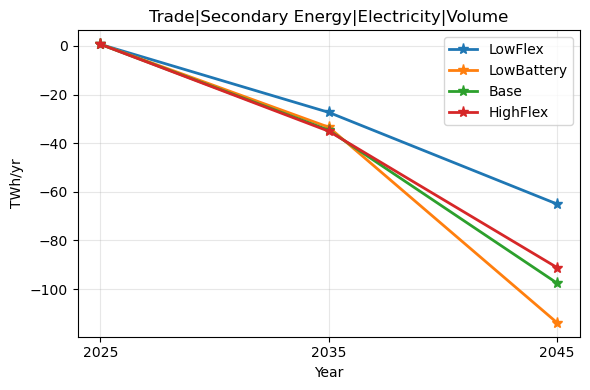

In [ ]:
# Trade
# plot_variable("Trade|Secondary Energy|Electricity|Gross Import|Volume", variables, scenarios)
plot_variable("Trade|Secondary Energy|Electricity|Volume", variables, scenarios)
# plot_variable("Trade|Secondary Energy|Hydrogen|Volume", variables, scenarios)
# plot_variable("Trade|Primary Energy|Biomass|Net Imports", variables, scenarios)
# plot_variable("Trade|Secondary Energy|Methanol|Volume", variables, scenarios)

In [ ]:
for scenario in scenarios:
    print(scenario)
    print(variables[scenario].loc["Trade|Secondary Energy|Electricity|Gross Import|Volume"])
    print()


LowFlex
            2025       2035       2045
Unit                                  
TWh/yr  98.62743  225.77337  251.52296

LowBattery
           2025       2035       2045
Unit                                 
TWh/yr  98.8769  225.85428  274.23774

Base
            2025       2035       2045
Unit                                  
TWh/yr  98.83467  217.47744  278.33489

HighFlex
            2025       2035       2045
Unit                                  
TWh/yr  98.78426  216.66448  275.38174



In [ ]:
for scenario in scenarios:
    print(scenario)
    print(variables[scenario].loc["Trade|Secondary Energy|Electricity|Volume"])
    print()

LowFlex
           2025      2035      2045
Unit                               
TWh/yr  0.67576 -27.30938 -65.03259

LowBattery
           2025      2035       2045
Unit                                
TWh/yr  0.71513 -33.40596 -113.88003

Base
           2025     2035      2045
Unit                              
TWh/yr  0.71048 -34.6356 -97.59062

HighFlex
           2025      2035      2045
Unit                               
TWh/yr  0.71096 -35.05672 -91.17429



In [ ]:
for year in [2035]:
        for scenario in scenarios:
            n = networks[(scenario, year)]

            # efuels trade volume
            exports_efuels, imports_efuels = get_export_import(
                n, region, ["renewable oil", "renewable gas", "methanol"]
                )
            variables[scenario].loc["Trade|Secondary Energy|Efuels|Volume", year] = (exports_efuels - imports_efuels) / 1e6 # TWh

            # methanol trade volume
            exports_methanol, imports_methanol = get_export_import(
                n, region, ["methanol"]
                )
            variables[scenario].loc["Trade|Secondary Energy|Efuels|Methanol|Volume", year] = (exports_methanol - imports_methanol) / 1e6 # TWh

            # renewable gas trade volume
            exports_renewable_gas, imports_renewable_gas = get_export_import(
                n, region, ["renewable gas"]
                )
            variables[scenario].loc["Trade|Secondary Energy|Efuels|Renewable Gas|Volume", year] = (exports_renewable_gas - imports_renewable_gas) / 1e6 # TWh

            # renewable oil trade volume
            exports_renewable_oil, imports_renewable_oil = get_export_import(
                n, region, ["renewable oil"]
                )   
            variables[scenario].loc["Trade|Secondary Energy|Efuels|Renewable Oil|Volume", year] = (exports_renewable_oil - imports_renewable_oil) / 1e6 # TWh


In [ ]:
scenario = "LowFlex"
year = 2045

variables[scenario].loc["Trade|Secondary Energy|Efuels|Volume", year]
# variables[scenario].loc["Trade|Secondary Energy|Electricity|Volume", year]

Unit
   -203.494215
Name: 2045, dtype: float64

In [ ]:
variables[scenario].loc["Trade|Secondary Energy|Hydrogen|Volume", year]

Unit
TWh/yr   -203.503
Name: 2045, dtype: float64

In [ ]:
import importlib
import flexibility_utils
importlib.reload(flexibility_utils)
from flexibility_utils import tech_colors

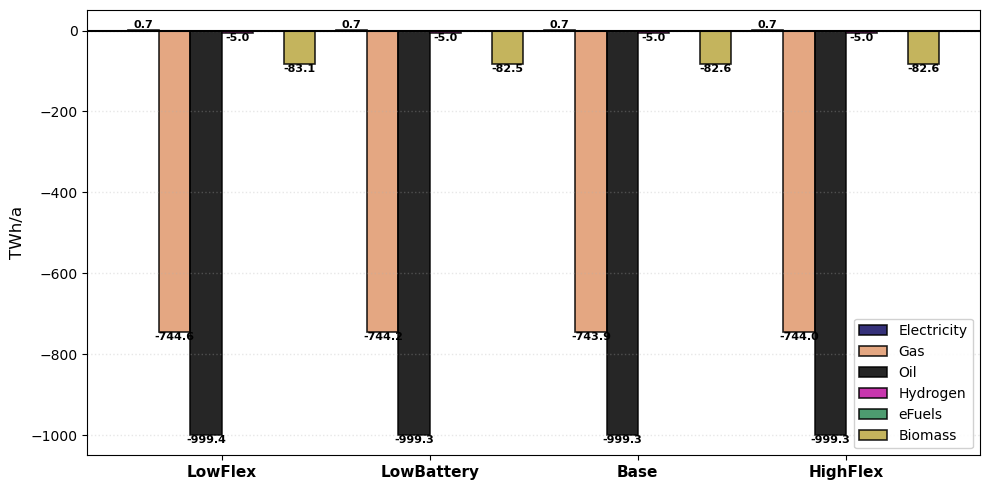

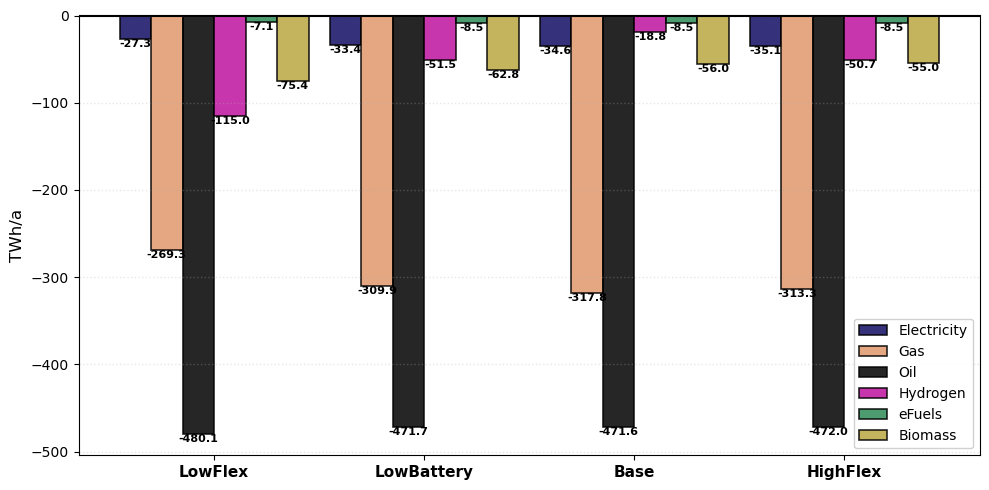

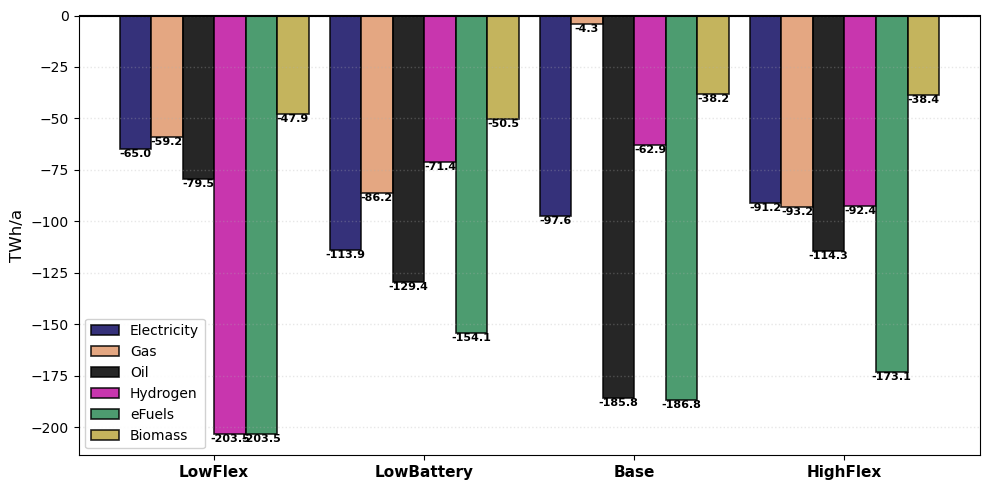

In [ ]:
plot_vars = {
    "Electricity": "Trade|Secondary Energy|Electricity|Volume",
    "Gas": "Primary Energy|Gas",
    "Oil": "Primary Energy|Oil",
    "Hydrogen": "Trade|Secondary Energy|Hydrogen|Volume", 
    "eFuels": "Trade|Secondary Energy|Efuels|Volume",
    "Biomass": "Trade|Primary Energy|Biomass|Net Imports",
}

bar_plot_variables(variables, 
                     scenarios = ['LowFlex', 'LowBattery', 'Base', 'HighFlex'], 
                     years = [2025, 2035, 2045],
                     tech_colors=dict(sector_colors, **tech_colors),
                     plot_vars=plot_vars,
                     sign_flip_vars=["Oil", "Gas", "Biomass"],
                     output_dir=PLOT_DIR)

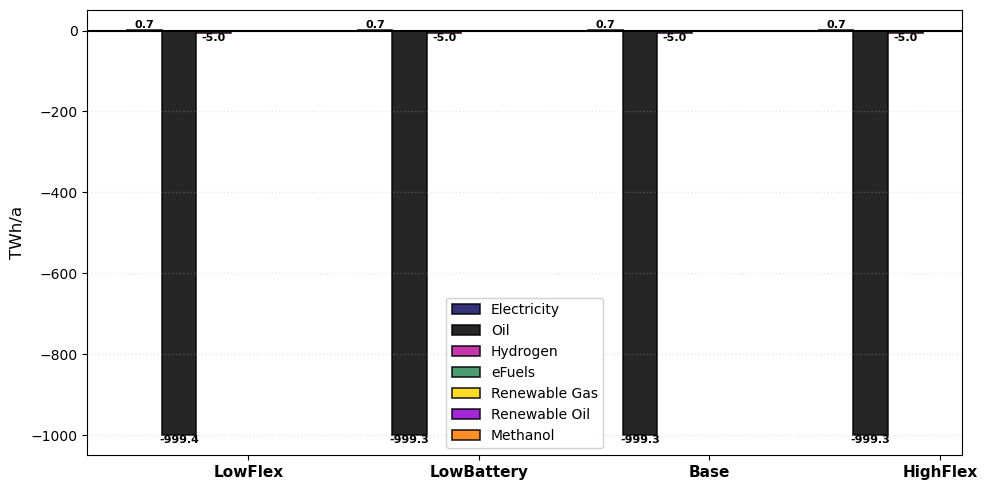

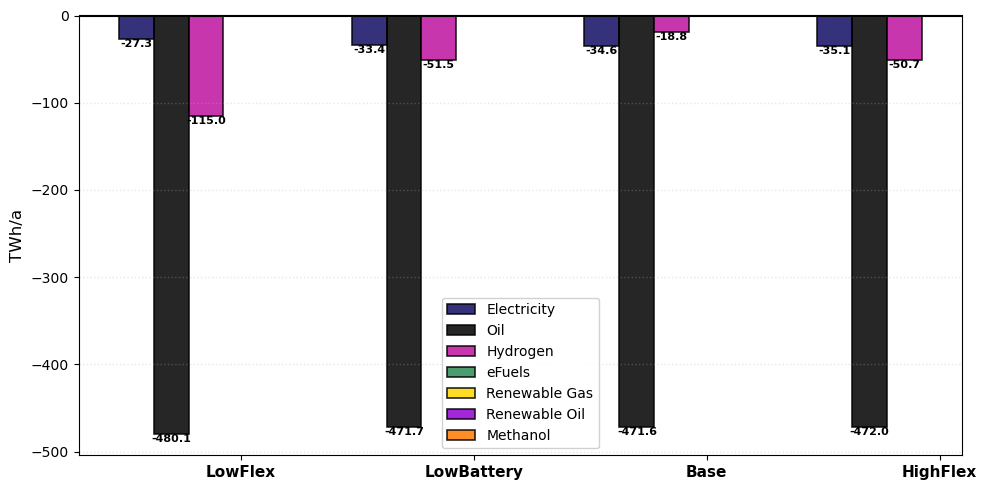

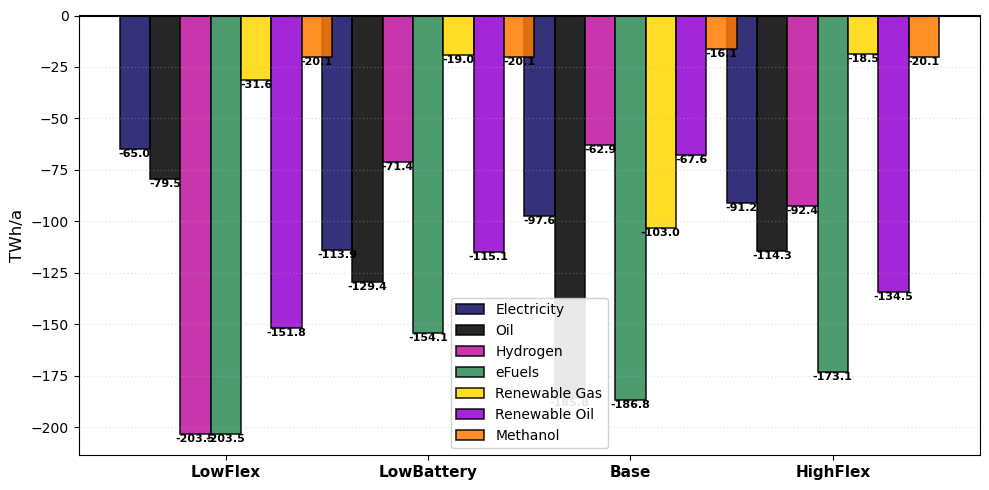

In [ ]:
plot_vars = {
    "Electricity": "Trade|Secondary Energy|Electricity|Volume",
    # "Gas": "Primary Energy|Gas",
    "Oil": "Primary Energy|Oil",
    "Hydrogen": "Trade|Secondary Energy|Hydrogen|Volume", 
    "eFuels": "Trade|Secondary Energy|Efuels|Volume",
    "Renewable Gas": "Trade|Secondary Energy|Efuels|Renewable Gas|Volume",
    "Renewable Oil": "Trade|Secondary Energy|Efuels|Renewable Oil|Volume",
    "Methanol": "Trade|Secondary Energy|Efuels|Methanol|Volume",
    # "Biomass": "Trade|Primary Energy|Biomass|Net Imports",
}

bar_plot_variables(variables, 
                     scenarios = ['LowFlex', 'LowBattery', 'Base', 'HighFlex'], 
                     years = [2025, 2035, 2045],
                     tech_colors=dict(sector_colors, **tech_colors),
                     plot_vars=plot_vars,
                     sign_flip_vars=["Oil"],
                     output_dir=PLOT_DIR)

In [ ]:
n = networks[("Base", 2045)]

In [ ]:
exports_efuels, imports_efuels = get_export_import(
    n, "DE", ["renewable oil", "renewable gas", "methanol"], aggregate=False
)
(exports_efuels - imports_efuels).values.sum() / 1e6

-186.79223639912826

In [ ]:
exports_meoh, imports_meoh = get_export_import(
    n, "DE", ["methanol"]
)
(exports_meoh - imports_meoh) / 1e6

In [ ]:
exports_renew_oil, imports_renew_oil = get_export_import(
    n, "DE", ["renewable oil"]
)
(exports_renew_oil - imports_renew_oil) / 1e6

-67.64133507568131

In [ ]:
exports_renew_gas, imports_renew_gas = get_export_import(
    n, "DE", ["renewable gas"], aggregate=False
)
(exports_renew_gas - imports_renew_gas).values.sum() / 1e6

-103.03445117814944

In [ ]:
carrier = "renewable oil" 
gen = (
n.statistics.supply(
    bus_carrier=carrier,
    **kwargs,
)
.filter(like="DE")
.groupby("carrier")
.sum()
)
print(carrier, "\n", gen / 1e6)
print()
carrier = "oil" 
gen = (
n.statistics.supply(
    bus_carrier=carrier,
    **kwargs,
)
.filter(like="DE")
.groupby("carrier")
.sum()
)
print(carrier, "\n", gen / 1e6)

renewable oil 
 carrier
Fischer-Tropsch         4.142248
biomass to liquid       0.081833
biomass to liquid CC    9.568082
Name: objective, dtype: float64



oil 
 carrier
oil                0.866993
oil refining     176.429931
renewable oil     81.433485
dtype: float64


In [ ]:
generation_gas = (
    n.statistics.supply(
        bus_carrier=["gas"],
        **kwargs,
    )
    .filter(like="DE")
    .groupby("carrier")
    .sum()
)
generation_gas / 1e6

carrier
gas                 0.002265
gas compressing    56.800793
renewable gas      63.453275
dtype: float64

In [ ]:
consumption_renewable_gas = (
    n.statistics.withdrawal(
        bus_carrier=["renewable gas"],
        **kwargs,
    )
    .filter(like="DE")
    .groupby("carrier")
    .sum()
)
consumption_renewable_gas / 1e6

carrier
Sabatier         2.000000e-10
renewable gas    3.187453e+01
Name: objective, dtype: float64

In [ ]:
consumption_gas = (
    n.statistics.withdrawal(
        bus_carrier=["gas"],
        **kwargs,
    )
    .filter(like="DE")
    .groupby("carrier")
    .sum()
)
consumption_gas / 1e6

carrier
CCGT                         7.413293
OCGT                         0.010794
SMR                          0.001168
SMR CC                       0.000063
gas                          0.002265
gas for industry            88.526500
gas for industry CC          0.003889
urban central gas CHP       24.298071
urban central gas CHP CC     0.000189
urban central gas boiler     0.000100
dtype: float64

In [ ]:
for year in [2045]:
        for scenario in scenarios:
            n = networks[(scenario, year)]

            # trade costs
            tsc_sum, tsc = get_tsc(n, region, return_full=True)

            biomass_import_ind = tsc[tsc.index.str.contains("biomass transported")].index
            variables[scenario].loc["Total Energy System Cost|Trade|Biomass", year] = tsc.loc[biomass_import_ind, "opex"].sum().sum() / 1e9
            tsc.loc[biomass_import_ind, "opex"] = 0

            gas_import_ind = tsc[tsc.carrier == "gas primary"].index
            variables[scenario].loc["Total Energy System Cost|Trade|Gas", year] = tsc.loc[gas_import_ind, "opex"].sum().sum() / 1e9
            tsc.loc[gas_import_ind, "opex"] = 0

            oil_import_ind = tsc[tsc.carrier == "oil primary"].index
            variables[scenario].loc["Total Energy System Cost|Trade|Oil", year] = tsc.loc[oil_import_ind, "opex"].sum().sum() / 1e9
            tsc.loc[oil_import_ind, "opex"] = 0

            # coal imports
            lignite_ind = n.links[(n.links.carrier=="lignite") & (n.links.bus1.str.contains("DE"))].index
            lignite_cost = (n.links_t.p0[lignite_ind].sum(axis=1) * n.buses_t.marginal_price["EU lignite"]).sum() / 1e9

            coal_ind = n.links[(n.links.carrier=="coal") & (n.links.bus1.str.contains("DE"))].index
            coal_cost = (n.links_t.p0[coal_ind].sum(axis=1) * n.buses_t.marginal_price["EU coal"]).sum() / 1e9

            variables[scenario].loc["Total Energy System Cost|Trade|Coal", year] = lignite_cost + coal_cost

            variables[scenario].loc["Total Energy System Cost|Trade|Efuels|Renewable Oil", year] = (
                get_trade_cost(n, region, ["renewable oil"]) / 1e9
            )
            variables[scenario].loc["Total Energy System Cost|Trade|Efuels|Renewable Gas", year] = (
                get_trade_cost(n, region, ["renewable gas"]) / 1e9
            )
            variables[scenario].loc["Total Energy System Cost|Trade|Efuels|Methanol", year] = (
                get_trade_cost(n, region, ["methanol"]) / 1e9
            )   

In [ ]:
scenario = "LowFlex"
year = 2045

variables[scenario].loc["Total Energy System Cost|Trade|Efuels|Renewable Gas", year]
variables[scenario].loc["Total Energy System Cost|Trade|Electricity", year]

Unit
NaN    10.65769
Name: 2045, dtype: float64

## Trade Cost
- How come that the amount of efuel trade is much larger than that of electricity but the import costs are lower?

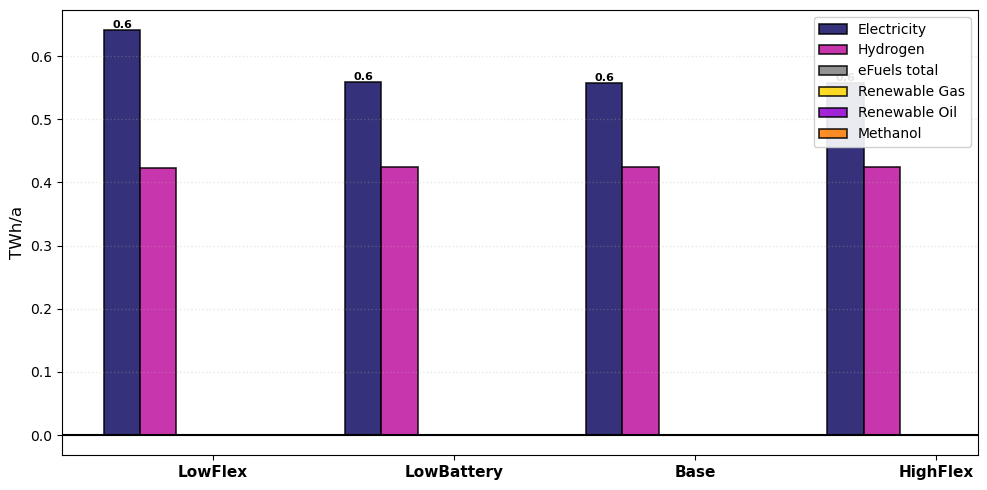

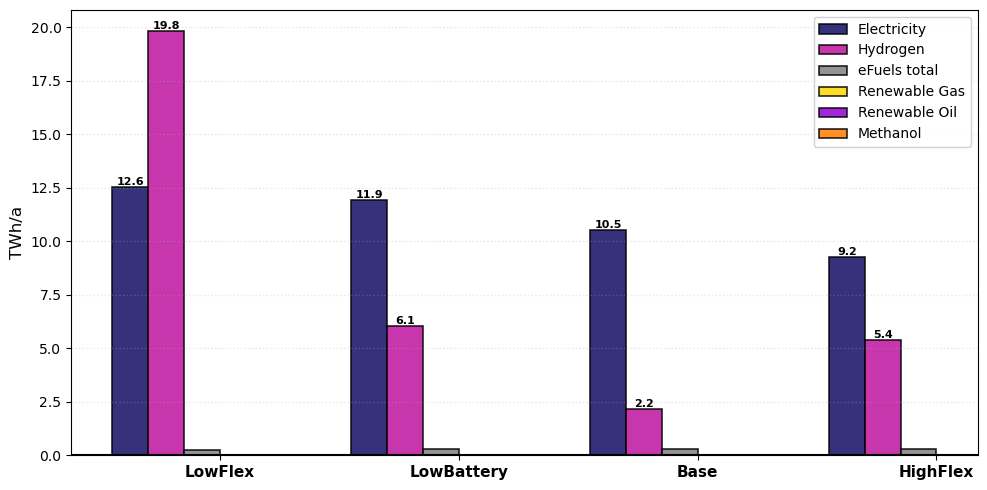

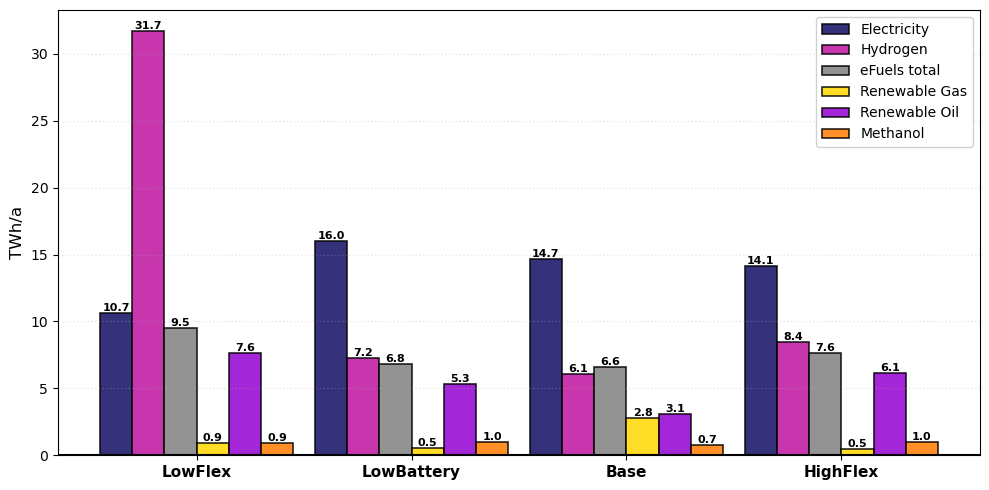

In [ ]:
plot_vars = {
    "Electricity": "Total Energy System Cost|Trade|Electricity",
    # "Gas": "Total Energy System Cost|Trade|Gas",
    # "Oil": "Total Energy System Cost|Trade|Oil",
    "Hydrogen": "Total Energy System Cost|Trade|Hydrogen", 
    "eFuels total": "Total Energy System Cost|Trade|Efuels",
    "Renewable Gas": "Total Energy System Cost|Trade|Efuels|Renewable Gas",
    "Renewable Oil": "Total Energy System Cost|Trade|Efuels|Renewable Oil",
    "Methanol": "Total Energy System Cost|Trade|Efuels|Methanol",
    # "Biomass": "Total Energy System Cost|Trade|Biomass",
}

bar_plot_variables(variables, 
                     scenarios = ['LowFlex', 'LowBattery', 'Base', 'HighFlex'], 
                     years = [2025, 2035, 2045],
                     tech_colors=dict(sector_colors, **tech_colors),
                     plot_vars=plot_vars,
                     sign_flip_vars=[],
                     output_dir=PLOT_DIR)

In [9]:
# average prices on map

scenario = "Base"
year = 2045

n = networks[(scenario, year)]
carrier = "co2"

ind = n.buses.index[n.buses.carrier == carrier]
avg_price = n.buses_t.marginal_price[ind].mean()
avg_price

# avg system prices BAse 2045: 
# renewable gas 27 €/MWh (e.g. trade volume Base in 2045 is 103 TWh and costs are 2.8 billion €, so 2.8 billion € / 103 TWh = 27 €/MWh)
# renewable oil 46 €/MWh
# methanol 52 €/MWh
# AC 77 €/MWh
# low voltage 94 €/MWh
# H2: 94 €/MWh
# oil primary: 38 €/MWh
# co2: 400 €/tonne


Bus
co2 atmosphere   -407.808099
dtype: float64

In [12]:
n.global_constraints.loc["CO2Limit", "mu"]

-407.8188595189623

In [10]:
n.global_constraints.loc["co2_limit-DE", "mu"]

-0.052453821107535846

# Curtailment

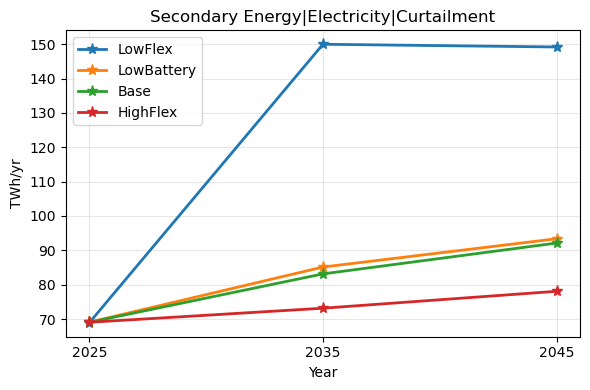

In [ ]:
plot_variable('Secondary Energy|Electricity|Curtailment', variables, scenarios)

In [ ]:
year = 2045

networks = {}
for scenario in scenarios:
        fn = f"{f}/{run}/{scenario}/networks/base_s_{clusters}__none_{year}.nc"
        networks[(scenario, year)] = pypsa.Network(fn)

INFO:pypsa.network.io:New version 1.0.3 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.3 available! (Current: 0.35.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.network.io:New version 1.0.3 available! (Current: 0.35.1)


KeyboardInterrupt: 

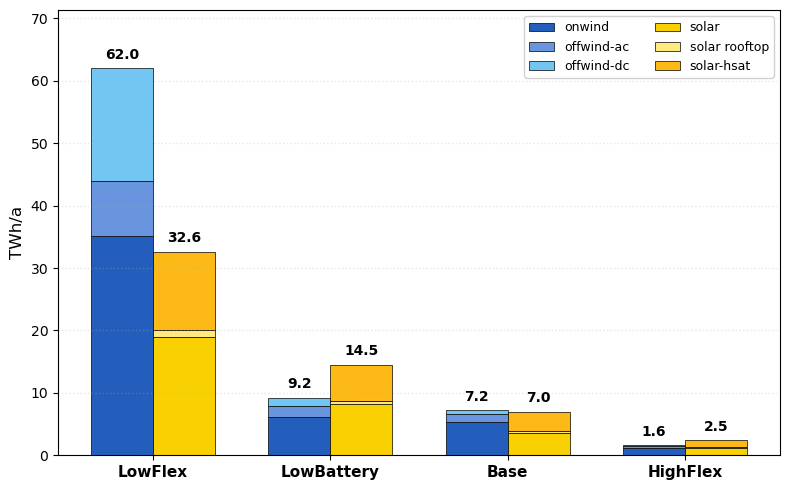

In [ ]:
year = 2035
plot_curtailment(networks, 
                 ['LowFlex', 'LowBattery', 'Base', 'HighFlex'], 
                 year, 
                 tech_colors,
                 PLOT_DIR)

In [ ]:
assert 0

AssertionError: 

# Testing

## Dispatchable

In [ ]:
n = networks[("Base", 2035)]

cf_electricity = (
    n.statistics.capacity_factor(
        bus_carrier=["AC", "low voltage"],
        **kwargs,
    )
    .filter(like="DE")
    .groupby("carrier")
    .sum()
)

cf_electricity[
    cf_electricity.index.str.contains(
        "CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP", case=False
    )
]
cf = generation_electricity / capacities_electricity / 1e3
cf[cf.index.str.contains("CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP", case=False)]
disp_capa = (
    capacities_electricity[
        capacities_electricity.index.str.contains(
            "CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP", case=False
        )
    ]
    / 1e3
)
disp_gen = (
    generation_electricity[
        generation_electricity.index.str.contains(
            "CCGT|OCGT|gas|H2 retrofit|H2 turbine|H2 CHP", case=False
        )
    ]
    / 1e6
)
disp_cf = disp_gen / (disp_capa * 2920) * 1e3
pd.concat(
    [disp_capa, disp_gen, disp_cf],
    axis=1,
    keys=["Capacity [GW]", "Generation [TWh]", "Capacity Factor"],
)

# load pkl
import pickle

fn = "/home/julian-geis/Documents/06_PhD/02Flexibility/runs/20251015-flex-scenario-update-27cl-3h/Base/flexibility/data/flexibility_contributions_raw.pkl"
with open(fn, "rb") as f:
    flexibility_data = pickle.load(f)
    flexibility_data[2045].loc["weekly"].loc[
        [
            "Supply_H2 OCGT",
            "Supply_CCGT",
            "Supply_urban central H2 CHP",
            "Supply_urban central gas CHP",
        ]
    ]

## Percentage Scenarios

In [ ]:
capacities = pd.read_csv(
    "/home/julian-geis/repos/pypsa-de-flex/flex-data/Base_capacities_27cl_3H.csv",
    index_col=[0, 1, 2],
)

In [ ]:
year = 2045
carrier = "urban central water pits discharger"  # "H2 Electrolysis"
n = networks[("LowFlex50", year)]
n.links[(n.links.carrier == carrier) & (n.links.index.str.startswith("DE"))][
    ["p_nom_opt", "p_nom_max"]
]  # .sum()

In [ ]:
capacities[str(year)].xs(carrier, level=2) / 2

In [ ]:
capacities[str(year)].xs(carrier, level=2).sum() / 1e3

In [ ]:
restrict_carriers = [
    "battery discharger",
    "rural air heat pump",
    "rural ground heat pump",
    "rural resistive heater",
    "urban central air heat pump",
    "urban central resistive heater",
    "urban decentral air heat pump",
    "urban decentral resistive heater",
    "H2 Electrolysis",
    "urban central water pits discharger",
    "urban central water tanks discharger",
    #   "urban decentral water pits discharger",
    "urban decentral water tanks discharger",
    "H2 Store",
]
capacities.groupby("carrier").sum().loc[restrict_carriers] / 1e3